# 03 - Exploratory Data Analysis

## Online Retail Sales & Customer Analysis

This notebook explores the cleaned Online Retail transaction data to identify patterns in sales performance, products, customers, and geography.

The analysis builds on the data-understanding and cleaning stages. Rather than examining variables in isolation, the exploratory analysis focuses on questions that can provide meaningful insights into the business and guide subsequent customer-level analysis.

The main objectives are to:

* understand overall sales and transaction patterns;
* examine sales performance over time;
* identify important products and product-level patterns;
* explore geographic differences in sales;
* examine customer purchasing activity;
* identify patterns and questions that should be investigated in later analysis.

## 1. Load the Cleaned Dataset

The exploratory analysis is performed on the cleaned dataset produced in the data-cleaning stage.

The cleaning process removed exact duplicate records, standardized the `CustomerID` data type, and retained unusual transaction values where their meaning could not be determined reliably from the data alone.

Loading the cleaned dataset ensures that the exploratory analysis uses a consistent version of the data without repeating the cleaning process.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load Data

df = pd.read_csv(
    "../data/processed/cleaned_online_retail.csv",
    parse_dates=["InvoiceDate"]
)

In [3]:
df["InvoiceDate"].dtype

dtype('<M8[us]')

In [4]:
df["InvoiceDate"].dt.month

0         12
1         12
2         12
3         12
4         12
          ..
536636    12
536637    12
536638    12
536639    12
536640    12
Name: InvoiceDate, Length: 536641, dtype: int32

In [5]:
df["InvoiceDate"].dt.year

0         2010
1         2010
2         2010
3         2010
4         2010
          ... 
536636    2011
536637    2011
536638    2011
536639    2011
536640    2011
Name: InvoiceDate, Length: 536641, dtype: int32

In [6]:
df.shape

(536641, 9)

In [7]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
Revenue               float64
dtype: object

In [8]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
Revenue             0
dtype: int64

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### 1.1 Restore CustomerID Data Type

When the cleaned dataset is saved as CSV and loaded again, Pandas may infer `CustomerID` as a floating-point column because the column contains missing values.

Since `CustomerID` is an identifier rather than a numerical measurement, it is converted back to Pandas' nullable `Int64` type for consistency with the cleaned dataset.

In [10]:
df["CustomerID"] = df["CustomerID"].astype("Int64")

In [11]:
df["CustomerID"].dtype

Int64Dtype()

## 2. Overall Business Overview

Before examining individual products, customers, or countries, it is useful to establish a baseline view of the dataset.

This section summarizes the overall scale of the transactions and the period covered by the data. The purpose is to understand the size and scope of the business represented in the dataset before investigating more detailed patterns.

The analysis will examine:

* total net revenue;
* total transaction lines;
* total invoices;
* total units recorded;
* the time period covered by the dataset.

### 2.1 Data Period

The transaction data covers the period from **1 December 2010** to **9 December 2011**.

Understanding the time range is important for interpreting sales trends and identifying possible seasonal patterns. Since the dataset spans approximately one year, monthly and time-based comparisons can provide useful insight into how sales activity changes throughout the observed period.


In [12]:
df["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [13]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

### 2.2 Overall Business Activity

The cleaned dataset contains **536,641 transaction lines** across **25,900 unique invoices**. The total recorded quantity is **5,162,502 units**, and the resulting net revenue is approximately **£9.73 million**.

These figures provide a baseline for the scale of the business represented in the dataset. The transaction-line count is substantially higher than the invoice count because a single invoice can contain multiple transaction lines.

The revenue and quantity totals include negative transactions, which are retained because they may represent returns, cancellations, or other negative adjustments. Therefore, the revenue reported here represents **net recorded revenue** rather than gross sales before such transactions.

In [14]:
df["Revenue"].sum()

np.float64(9726006.954)

In [15]:
len(df)

536641

In [16]:
df["InvoiceNo"].nunique()

25900

In [17]:
df["Quantity"].sum()

np.int64(5162502)

### 2.3 Dataset Entities

The dataset contains **4,372 identified customers**, **4,070 unique products**, and transactions from **38 countries**.

The customer count represents only transactions with an identified `CustomerID`. Missing customer identifiers are not counted as customers because they cannot be reliably attributed to a specific customer.

These figures provide an overview of the main entities represented in the dataset and establish the baseline for the more detailed product, geographic, and customer analyses that follow.

In [18]:
df["CustomerID"].nunique()

4372

In [19]:
df["StockCode"].nunique()

4070

In [20]:
df["Country"].nunique()

38

## 3. Sales Over Time

After establishing the overall scale of the dataset, the next step is to examine how sales activity changes over time.

Aggregating transactions by month allows us to identify overall trends, periods of increased or decreased activity, and potential seasonal patterns. This provides a clearer view of the business than examining individual transaction timestamps.

The initial focus will be on monthly revenue, followed by other measures of sales activity where useful.

In [21]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [22]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

In [23]:
monthly_revenue

Month
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     681386.460
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: Revenue, dtype: float64

In [24]:
len(monthly_revenue)

13

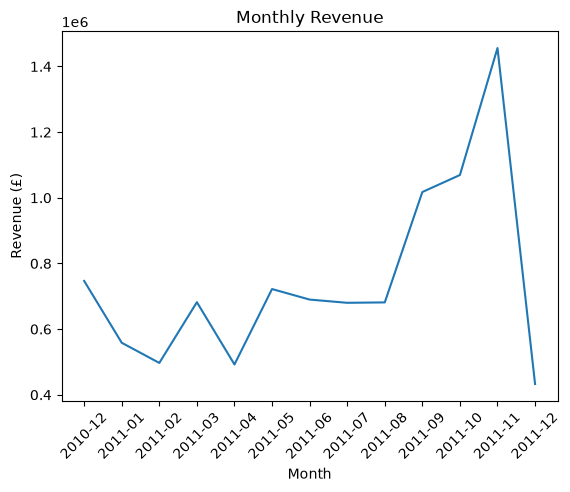

In [25]:
plt.plot(monthly_revenue.index.astype(str), monthly_revenue)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.show()

In [26]:
monthly_invoices = df.groupby("Month")["InvoiceNo"].nunique()

In [27]:
monthly_invoices

Month
2010-12    2025
2011-01    1476
2011-02    1393
2011-03    1983
2011-04    1744
2011-05    2162
2011-06    2012
2011-07    1927
2011-08    1737
2011-09    2327
2011-10    2637
2011-11    3462
2011-12    1015
Freq: M, Name: InvoiceNo, dtype: int64

In [28]:
monthly_units = df.groupby("Month")["Quantity"].sum()

In [29]:
monthly_units

Month
2010-12    341038
2011-01    308281
2011-02    277374
2011-03    351165
2011-04    288237
2011-05    379652
2011-06    340945
2011-07    389051
2011-08    405450
2011-09    548669
2011-10    569749
2011-11    737182
2011-12    225709
Freq: M, Name: Quantity, dtype: int64

In [30]:
invoice_revenue = df.groupby(["Month", "InvoiceNo"])["Revenue"].sum()

In [31]:
invoice_revenue

Month    InvoiceNo
2010-12  536365          139.12
         536366           22.20
         536367          278.73
         536368           70.05
         536369           17.85
                        ...    
2011-12  C581484     -168469.60
         C581490         -32.53
         C581499        -224.69
         C581568         -54.75
         C581569          -7.50
Name: Revenue, Length: 25900, dtype: float64

In [32]:
monthly_avg_revenue_per_invoice = invoice_revenue.groupby("Month").mean()

In [33]:
monthly_avg_revenue_per_invoice

Month
2010-12    368.752400
2011-01    378.352683
2011-02    356.802879
2011-03    343.930398
2011-04    282.321010
2011-05    333.993571
2011-06    342.931029
2011-07    352.961594
2011-08    392.277755
2011-09    437.299820
2011-10    405.524547
2011-11    420.608261
2011-12    426.306463
Freq: M, Name: Revenue, dtype: float64

### 3.1 Findings

Monthly revenue shows a relatively weaker sales period during the beginning of the year, followed by more stable activity from approximately May to August. Revenue then increases substantially from September through November, with November recording the highest monthly revenue in the dataset.

The increase in revenue during September–November is accompanied by increases in both the number of invoices and the number of units recorded. Average revenue per invoice also remains relatively high during this period, but does not increase as sharply as total revenue. This suggests that the increase in total revenue is primarily associated with higher sales activity and volume, rather than a large increase in revenue generated by each individual invoice.

December should be interpreted cautiously because the dataset only contains transactions through **9 December 2011**, making it a partial month rather than a complete comparison with the preceding months.


In [34]:
df["Revenue"].describe()

count    536641.000000
mean         18.123861
std         380.656263
min     -168469.600000
25%           3.750000
50%           9.870000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

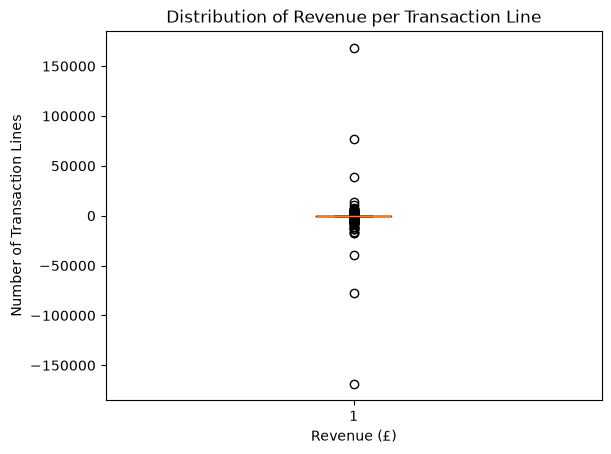

In [35]:
plt.boxplot(df["Revenue"])
plt.title("Distribution of Revenue per Transaction Line")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Transaction Lines")
plt.show()

### 3.2 Revenue Distribution

The revenue distribution is highly concentrated around relatively small transaction values, while a small number of observations have extremely large positive or negative values. These extreme observations stretch the scale of the histogram and make the distribution of typical transaction revenues difficult to observe.

The box plot confirms the presence of substantial outliers in transaction-level revenue. These observations are retained because they may represent legitimate high-value transactions, returns, or special transaction records identified during the data-cleaning stage.

In [36]:
product_revenue = df.groupby("StockCode")["Revenue"].sum()
product_revenue

StockCode
10002           759.89
10080           119.09
10120            40.32
10123C            3.25
10123G            0.00
                 ...  
gift_0001_20    167.05
gift_0001_30    175.53
gift_0001_40    100.70
gift_0001_50    167.56
m                 2.55
Name: Revenue, Length: 4070, dtype: float64

In [37]:
top_products = product_revenue.nlargest(20)
top_products

StockCode
DOT       206245.48
22423     164459.49
47566      98243.88
85123A     97838.45
85099B     92175.79
23084      66661.63
POST       66230.64
22086      63715.24
84879      58792.42
79321      53746.66
22502      51023.52
22197      50967.92
23298      42665.37
22386      41584.43
23203      40953.94
21137      40578.21
22720      37378.79
23284      36532.39
22960      36069.34
82484      35795.97
Name: Revenue, dtype: float64

### we're here noww to adjust

In [38]:
df["StockCode"].unique()

<StringArray>
['85123A',  '71053', '84406B', '84029G', '84029E',  '22752',  '21730',
  '22633',  '22632',  '84879',
 ...
  '23560',  '23576',  '23562',  '23561',  '23609', '85179a',  '23617',
 '90214U', '47591b',  '23843']
Length: 4070, dtype: str

In [39]:
stock_codes = pd.Series(df["StockCode"].dropna().unique())
is_numeric = stock_codes.str.isdigit()
is_numeric.value_counts()

True     2946
False    1124
Name: count, dtype: int64

In [40]:
non_numeric_codes = stock_codes[~is_numeric]
non_numeric_codes.head(30)

0       85123A
2       84406B
3       84029G
4       84029E
45        POST
55      82494L
60      85099C
63      84997B
64      84997C
73      84519A
74      85183B
75      85071B
93      37444A
94      37444C
96      84971S
103    15056BL
104     15056N
111          D
121     35004C
136     85049A
140     85099B
156     35004G
157     85014B
158     85014A
167     84970S
177     84030E
209     35004B
227     85049E
229     17091A
231     84509A
dtype: str

In [41]:
non_numeric_codes.str.len().value_counts().sort_values()

2        1
3        1
9        3
4        3
7        4
1        5
12       6
8       14
6     1087
Name: count, dtype: int64

In [42]:
has_digit = non_numeric_codes.str.contains(r"\d")
has_digit.value_counts()

True     1111
False      13
Name: count, dtype: int64

In [43]:
has_no_digit = non_numeric_codes[~has_digit]
has_no_digit

45              POST
111                D
952              DOT
1115               M
1542    BANK CHARGES
2242               S
2245       AMAZONFEE
2791               m
3078        DCGSSBOY
3079       DCGSSGIRL
3328            PADS
3753               B
3772            CRUK
dtype: str

In [44]:
special_candidates = df[
    df["StockCode"].isin(has_no_digit)
][["StockCode", "Description", "Quantity", "UnitPrice", "Revenue"]]

special_candidates.drop_duplicates().sort_values("StockCode")

,StockCode,Description,Quantity,UnitPrice,Revenue
189761,AMAZONFEE,AMAZON FEE,-1,5876.40,-5876.40
519496,AMAZONFEE,AMAZON FEE,-1,11586.50,-11586.50
95932,AMAZONFEE,AMAZON FEE,-1,5258.77,-5258.77
284834,AMAZONFEE,AMAZON FEE,-1,4575.64,-4575.64
284881,AMAZONFEE,AMAZON FEE,-1,6721.37,-6721.37
...,...,...,...,...,...
95775,S,SAMPLES,-1,8.74,-8.74
95776,S,SAMPLES,-1,9.74,-9.74
95800,S,SAMPLES,-1,37.49,-37.49
95799,S,SAMPLES,-1,39.50,-39.50


NB:

For the purpose of this project's product-performance analysis, we define the product universe using this observed coding structure, after validating the digit-free exceptions against their descriptions.

In [45]:
has_digit_df = df["StockCode"].str.contains(r"\d")

In [46]:
product_df = df[has_digit_df]
product_df.shape

(533851, 10)

In [47]:
product_df["Revenue"].sum()

np.float64(9778694.99)

In [48]:
df.shape[0] - product_df.shape[0]

2790

In [49]:
df["Revenue"].sum() - product_df["Revenue"].sum()

np.float64(-52688.03600000031)

In [50]:
excluded_codes = df.loc[~has_digit_df, "StockCode"].unique()

excluded_codes

<StringArray>
[        'POST',            'D',          'DOT',            'M',
 'BANK CHARGES',            'S',    'AMAZONFEE',            'm',
     'DCGSSBOY',    'DCGSSGIRL',         'PADS',            'B',
         'CRUK']
Length: 13, dtype: str

In [51]:
underscore_codes = stock_codes[stock_codes.str.contains("a", regex=False)].sort_values()

underscore_codes

2467    35809a
4003    46776a
2294    72351a
3654    72802a
2958    72807a
3556    82613a
4009    84031a
3068    84509a
2474    84510a
3082    84536a
2302    84558a
1659    84559a
3526    84660a
3495    84661a
2651    84796a
1631    84872a
1661    84884a
2470    84968a
2286    84989a
3055    84993a
2992    84997a
1662    85014a
3503    85034a
2476    85035a
3671    85036a
1634    85039a
2955    85040a
1798    85049a
2655    85114a
1801    85123a
2299    85132a
2790    85160a
4065    85179a
dtype: str

In [52]:
df[
    df["StockCode"].isin(["35809a"])
][["Description"]].drop_duplicates().value_counts()

Description              
ENAMEL PINK TEA CONTAINER    1
Name: count, dtype: int64

## pause

In [55]:
df[df["StockCode"] == "DOT"][["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Revenue"]].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
1778,536544,DOT,DOTCOM POSTAGE,1,569.77,569.77
2997,536592,DOT,DOTCOM POSTAGE,1,607.49,607.49
5365,536862,DOT,DOTCOM POSTAGE,1,254.43,254.43
5454,536864,DOT,DOTCOM POSTAGE,1,121.06,121.06
5594,536865,DOT,DOTCOM POSTAGE,1,498.47,498.47
6068,536876,DOT,DOTCOM POSTAGE,1,887.52,887.52
10605,537237,DOT,DOTCOM POSTAGE,1,863.74,863.74
11174,537240,DOT,DOTCOM POSTAGE,1,940.87,940.87
13670,537434,DOT,DOTCOM POSTAGE,1,950.99,950.99
15390,537638,DOT,DOTCOM POSTAGE,1,836.14,836.14


In [56]:
df[df["StockCode"].isin(top_products.index)][
    ["StockCode", "Description"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description
183558,21137,NaN
848,21137,BLACK RECORD COVER FRAME
46,22086,PAPER CHAIN KIT 50'S CHRISTMAS
221325,22197,POPCORN HOLDER
221,22197,SMALL POPCORN HOLDER
86,22386,JUMBO BAG PINK POLKADOT
113399,22423,damages
21020,22423,faulty
858,22423,REGENCY CAKESTAND 3 TIER
220825,22502,PICNIC BASKET WICKER 60 PIECES


In [57]:
special_codes = ["DOT", "POST", "D", "M", "m", "AMAZONFEE", "B"]

In [58]:
# New df excluding the special codes for non-products
product_df = df[~df["StockCode"].isin(special_codes)]

In [59]:
product_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Month'],
      dtype='str')

In [60]:
product_df.shape

(533994, 10)

In [61]:
product_revenue_clean = product_df.groupby("StockCode")["Revenue"].sum()

In [62]:
product_revenue_clean.nlargest(10)

StockCode
22423     164459.49
47566      98243.88
85123A     97838.45
85099B     92175.79
23084      66661.63
22086      63715.24
84879      58792.42
79321      53746.66
22502      51023.52
22197      50967.92
Name: Revenue, dtype: float64

In [63]:
product_df[product_df["StockCode"].isin(product_revenue_clean.nlargest(10).index)][
    ["StockCode", "Description"]
].drop_duplicates()

,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
9,84879,ASSORTED COLOUR BIRD ORNAMENT
46,22086,PAPER CHAIN KIT 50'S CHRISTMAS
177,85099B,JUMBO BAG RED RETROSPOT
178,79321,CHILLI LIGHTS
221,22197,SMALL POPCORN HOLDER
249,22502,PICNIC BASKET WICKER SMALL
858,22423,REGENCY CAKESTAND 3 TIER
5444,47566,PARTY BUNTING
21020,22423,faulty


In [64]:
description_counts = (
    product_df
    .groupby(["StockCode", "Description"])
    .size()
    .sort_values(ascending=False)
)

In [65]:
description_counts

StockCode  Description                       
85123A     WHITE HANGING HEART T-LIGHT HOLDER    2290
22423      REGENCY CAKESTAND 3 TIER              2189
85099B     JUMBO BAG RED RETROSPOT               2156
47566      PARTY BUNTING                         1720
20725      LUNCH BAG RED RETROSPOT               1625
                                                 ... 
22700      smashed                                  1
22687      adjustment                               1
           had been put aside                       1
90210D     check                                    1
23530      WALL ART,ONLY ONE PERSON                 1
Length: 4785, dtype: int64

In [66]:
top_10_products = product_revenue_clean.nlargest(10)

top_10_descriptions = (
    description_counts
    .loc[
        description_counts.index.get_level_values("StockCode")
        .isin(top_10_products.index)
    ]
)

In [67]:
top_10_descriptions = (
    top_10_descriptions
    .groupby(level="StockCode")
    .head(1)
)

In [68]:
top_10_descriptions = (
    top_10_descriptions
    .groupby(level="StockCode", group_keys=False)
    .apply(lambda x: x.sort_values(ascending=False).head(1))
)

In [69]:
top_10_descriptions

StockCode  Description                       
85123A     WHITE HANGING HEART T-LIGHT HOLDER    2290
22423      REGENCY CAKESTAND 3 TIER              2189
85099B     JUMBO BAG RED RETROSPOT               2156
47566      PARTY BUNTING                         1720
84879      ASSORTED COLOUR BIRD ORNAMENT         1488
22086      PAPER CHAIN KIT 50'S CHRISTMAS        1194
23084      RABBIT NIGHT LIGHT                    1032
22197      POPCORN HOLDER                         861
79321      CHILLI LIGHTS                          676
22502      PICNIC BASKET WICKER SMALL             474
dtype: int64

In [70]:
top_10_product_table = (
    top_10_products.to_frame(name="Revenue")
    .merge(
        top_10_descriptions.reset_index(),
        left_index=True,
        right_on="StockCode"
    )
    [["StockCode", "Description", "Revenue"]]
)

In [71]:
top_10_product_table

,StockCode,Description,Revenue
1,22423,REGENCY CAKESTAND 3 TIER,164459.49
3,47566,PARTY BUNTING,98243.88
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,97838.45
2,85099B,JUMBO BAG RED RETROSPOT,92175.79
6,23084,RABBIT NIGHT LIGHT,66661.63
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
4,84879,ASSORTED COLOUR BIRD ORNAMENT,58792.42
8,79321,CHILLI LIGHTS,53746.66
9,22502,PICNIC BASKET WICKER SMALL,51023.52
7,22197,POPCORN HOLDER,50967.92


In [72]:
top_10_product_table = top_10_product_table.sort_values(
    "Revenue",
    ascending=False
).reset_index(drop=True)

In [73]:
top_10_product_table

,StockCode,Description,Revenue
0,22423,REGENCY CAKESTAND 3 TIER,164459.49
1,47566,PARTY BUNTING,98243.88
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,97838.45
3,85099B,JUMBO BAG RED RETROSPOT,92175.79
4,23084,RABBIT NIGHT LIGHT,66661.63
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
6,84879,ASSORTED COLOUR BIRD ORNAMENT,58792.42
7,79321,CHILLI LIGHTS,53746.66
8,22502,PICNIC BASKET WICKER SMALL,51023.52
9,22197,POPCORN HOLDER,50967.92


### 3.3 Top Product Performance

**Business question:** Which products generate the most revenue?

**Analytical question:** How much net recorded revenue was generated by each product, and which products were the top performers?

To answer this question, regular product transactions were analyzed after excluding special transaction codes that do not represent regular products (`DOT`, `POST`, `D`, `M`, `m`, `AMAZONFEE`, and `B`). Revenue was then aggregated by `StockCode` and the top 10 products were identified.

Because some `StockCode` values have inconsistent descriptions due to operational notes, adjustments, or damaged/faulty entries, the most frequently occurring description was selected as the representative product name for each top product.

**Key findings:**

- `22423` — **REGENCY CAKESTAND 3 TIER** generated the highest net recorded revenue among the regular products analyzed, at approximately **£164.46K**.
- `47566` — **PARTY BUNTING** ranked second, generating approximately **£98.24K**.
- `85123A` — **WHITE HANGING HEART T-LIGHT HOLDER** ranked third, generating approximately **£97.84K**.
- The remaining top products also generated substantial revenue, with the tenth-ranked product (`22197` — **POPCORN HOLDER**) generating approximately **£50.97K**.
- The ranking is based on **net recorded revenue**, meaning negative transactions such as returns or cancellations remain included in the calculation.
- Product descriptions were not assumed to be perfectly reliable. The most frequent description was used only as a representative label for readability.

### revise this part

## A2.

In [74]:
cumulative_revenue = product_revenue_clean.sort_values(ascending=False).cumsum()

In [75]:
cumulative_revenue

StockCode
22423            164459.490
47566            262703.370
85123A           360541.820
85099B           452717.610
23084            519379.240
                   ...     
85063           9779043.973
79323W          9778989.973
S               9775950.323
BANK CHARGES    9768774.684
CRUK            9760841.254
Name: Revenue, Length: 4063, dtype: float64

### Geographic

In [78]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(20)

Country
United Kingdom     8167128.184
Netherlands         284661.540
EIRE                262993.380
Germany             221509.470
France              197317.110
Australia           137009.770
Switzerland          56363.050
Spain                54756.030
Belgium              40910.960
Sweden               36585.410
Japan                35340.620
Norway               35163.460
Portugal             29302.970
Finland              22326.740
Channel Islands      20076.390
Denmark              18768.140
Italy                16890.510
Cyprus               12858.760
Austria              10154.320
Hong Kong             9908.240
Name: Revenue, dtype: float64

In [81]:
country_revenue_percentage = (
    country_revenue / country_revenue.sum() * 100
)

country_revenue_percentage

Country
United Kingdom          83.972058
Netherlands              2.926808
EIRE                     2.704022
Germany                  2.277497
France                   2.028758
Australia                1.408695
Switzerland              0.579509
Spain                    0.562986
Belgium                  0.420635
Sweden                   0.376161
Japan                    0.363362
Norway                   0.361541
Portugal                 0.301285
Finland                  0.229557
Channel Islands          0.206420
Denmark                  0.192969
Italy                    0.173663
Cyprus                   0.132210
Austria                  0.104404
Hong Kong                0.101874
Singapore                0.093773
Israel                   0.081246
Poland                   0.074163
Unspecified              0.048745
Greece                   0.048432
Iceland                  0.044314
Canada                   0.037697
Malta                    0.025761
United Arab Emirates     0.019559
USA   

In [87]:
country_customers = (
    df.dropna(subset=["CustomerID"])
      .groupby("Country")["CustomerID"]
      .nunique()
      .sort_values(ascending=False)
)

country_customers

Country
United Kingdom          3950
Germany                   95
France                    87
Spain                     31
Belgium                   25
Switzerland               21
Portugal                  19
Italy                     15
Finland                   12
Austria                   11
Norway                    10
Australia                  9
Denmark                    9
Netherlands                9
Channel Islands            9
Japan                      8
Sweden                     8
Cyprus                     8
Poland                     6
Unspecified                4
USA                        4
Canada                     4
Israel                     4
Greece                     4
EIRE                       3
United Arab Emirates       2
Bahrain                    2
Malta                      2
Brazil                     1
Lebanon                    1
Iceland                    1
Czech Republic             1
European Community         1
Saudi Arabia               1
RSA   

In [86]:
avg_revenue_per_customer = country_revenue / country_customers

avg_revenue_per_customer.sort_values(ascending=False)

Country
EIRE                    87664.460000
Netherlands             31629.060000
Australia               15223.307778
Singapore                9120.390000
Sweden                   4573.176250
Japan                    4417.577500
Iceland                  4310.000000
Norway                   3516.346000
Switzerland              2683.954762
Germany                  2331.678632
France                   2268.012759
Channel Islands          2230.710000
Denmark                  2085.348889
United Kingdom           2067.627388
Israel                   1975.492500
Finland                  1860.561667
Spain                    1766.323548
Lebanon                  1693.880000
Lithuania                1661.060000
Belgium                  1636.438400
Cyprus                   1607.345000
Portugal                 1542.261579
European Community       1291.750000
Malta                    1252.735000
Poland                   1202.190000
Unspecified              1185.235000
Greece                   1177.

### Geographic Findings

The geographic analysis shows that sales are highly concentrated in the United Kingdom. The UK accounts for approximately **84% of total recorded revenue**, substantially more than any other country in the dataset. This is consistent with the distribution of identified customers, with **3,950 customers in the UK**, compared with 95 in Germany and 87 in France.

The results therefore suggest that the UK's dominant contribution to total revenue is largely associated with its much larger customer base rather than exceptionally high revenue generated by each individual customer. The UK generated approximately **£2,068 in revenue per identified customer**.

However, revenue per customer varies considerably across countries. EIRE and the Netherlands, for example, show much higher revenue per identified customer than the UK. These values should be interpreted cautiously because some countries have very small numbers of identified customers, meaning that a small number of high-value customers can substantially affect the average.

For countries with revenue but no identified customers, revenue per customer cannot be calculated. This reflects missing customer identification rather than zero customer value.

Overall, the business has an international customer base across multiple countries, but its recorded revenue is **strongly dependent on the UK market**. Smaller international markets may have higher revenue per customer, but their contribution to total revenue remains substantially lower.


### Customer behaviour

In [110]:
customer_invoices = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
)

customer_invoices

CustomerID
14911    248
12748    224
17841    169
14606    128
15311    118
        ... 
18240      1
12378      1
18262      1
12361      1
12357      1
Name: InvoiceNo, Length: 4372, dtype: int64

In [111]:
customer_invoices.describe()

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64

In [112]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
)

customer_revenue.describe()

count      4372.000000
mean       1893.531433
std        8218.696204
min       -4287.630000
25%         291.795000
50%         644.070000
75%        1608.335000
max      279489.020000
Name: Revenue, dtype: float64

In [113]:
customer_summary = pd.concat(
    [customer_invoices, customer_revenue],
    axis=1
)

customer_summary

,InvoiceNo,Revenue
CustomerID,,
14911,248,132458.73
12748,224,28405.56
17841,169,39869.05
14606,128,11633.35
15311,118,59284.19
...,...,...
18240,1,422.58
12378,1,4008.62
18262,1,149.48


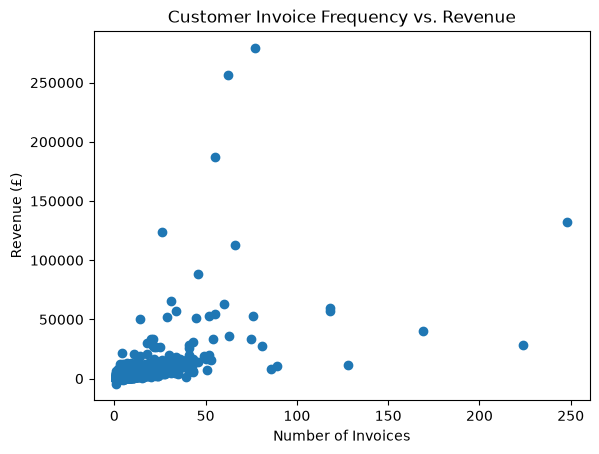

In [131]:
plt.scatter(customer_summary["InvoiceNo"], customer_summary["Revenue"])
plt.title("Customer Invoice Frequency vs. Revenue")
plt.xlabel("Number of Invoices")
plt.ylabel("Revenue (£)")
plt.show()

In [115]:
main_customers = customer_summary[
    (customer_summary["InvoiceNo"] < 50) &
    (customer_summary["Revenue"] < 50000)
]

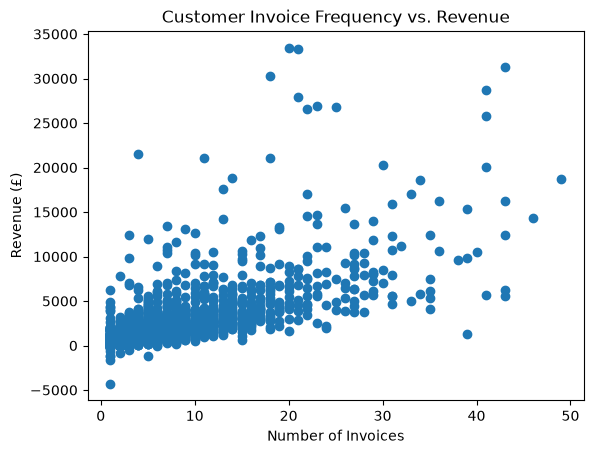

In [130]:
plt.scatter(main_customers["InvoiceNo"], main_customers["Revenue"])
plt.title("Customer Invoice Frequency vs. Revenue")
plt.xlabel("Number of Invoices")
plt.ylabel("Revenue (£)")
plt.show()

In [117]:
customer_summary["InvoiceNo"].corr(customer_summary["Revenue"])

np.float64(0.5655001070102927)

Customer purchase frequency is moderately positively associated with total revenue, suggesting that more active customers tend to generate greater customer value. However, the substantial variation in revenue among customers with similar invoice counts indicates that purchase frequency alone does not fully explain differences in customer value.

In [122]:
avg_revenue_per_invoice = (
    customer_summary["Revenue"] / customer_summary["InvoiceNo"]
)
avg_revenue_per_invoice.sort_values(ascending=False)

CustomerID
12357    6207.670000
15749    5383.975000
12688    4873.810000
12415    4758.671154
12752    4366.780000
            ...     
13154    -611.860000
12503   -1126.000000
14213   -1192.200000
15369   -1592.490000
17448   -4287.630000
Length: 4372, dtype: float64

In [125]:
avg_revenue_per_invoice.describe()

count    4372.000000
mean      314.492693
std       360.855433
min     -4287.630000
25%       151.430000
50%       235.154111
75%       366.518750
max      6207.670000
dtype: float64

In [ ]:
customer_summary["Revenue"].sort_values(ascending=False)

CustomerID
14646    279489.02
18102    256438.49
17450    187322.17
14911    132458.73
12415    123725.45
           ...    
12503     -1126.00
17603     -1165.30
14213     -1192.20
15369     -1592.49
17448     -4287.63
Name: Revenue, Length: 4372, dtype: float64

In [128]:
top_10_customers = customer_summary["Revenue"].sort_values(ascending=False).head(10)
top_10_customers

CustomerID
14646    279489.02
18102    256438.49
17450    187322.17
14911    132458.73
12415    123725.45
14156    113214.59
17511     88125.38
16684     65892.08
13694     62690.54
15311     59284.19
Name: Revenue, dtype: float64

In [135]:
top_10_customers

CustomerID
14646    279489.02
18102    256438.49
17450    187322.17
14911    132458.73
12415    123725.45
14156    113214.59
17511     88125.38
16684     65892.08
13694     62690.54
15311     59284.19
Name: Revenue, dtype: float64

In [ ]:
top_10_customers.index.dtype

Int64Dtype()

In [139]:
top_10_customers.index = top_10_customers.index.astype(str)

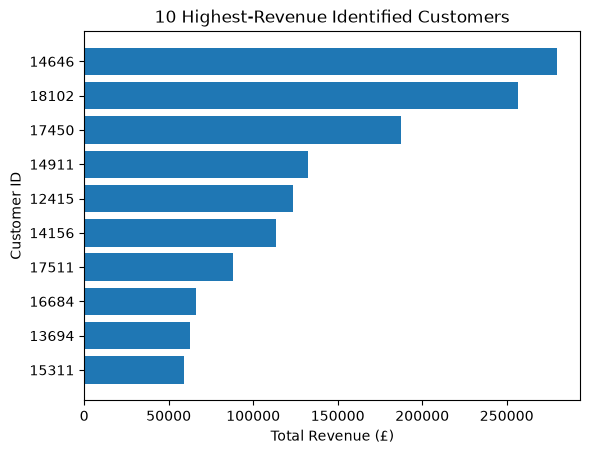

In [147]:
plt.barh(top_10_customers.index, top_10_customers.values)

plt.title("10 Highest-Revenue Identified Customers")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.show()

### Customer Revenue Findings

The customer-level revenue analysis shows that customer value is highly uneven across identified customers. The highest-revenue customer generated approximately £279,489 in net recorded revenue, while the 10th-highest generated approximately £59,284.

This indicates that a relatively small group of customers contributes a disproportionately large amount of recorded revenue. This is consistent with the earlier observation that the distribution of customer revenue is strongly right-skewed, with a median customer revenue of approximately £644 compared with a mean of approximately £1,894.

The analysis also shows that customer purchasing frequency and total revenue are positively related, but invoice frequency alone does not fully explain customer value. Customers with similar numbers of invoices can generate substantially different amounts of revenue.

Overall, the results suggest that customer value varies considerably across the customer base, with a smaller group of high-value customers standing out from the majority. This provides a useful basis for later customer segmentation or RFM analysis.


# Final EDA Summary

The exploratory analysis examined sales performance, products, geographic distribution, and customer purchasing behavior in the cleaned Online Retail dataset.

### Sales Performance

The dataset covers transactions from December 2010 to December 2011, with December 2011 representing only a partial month. After cleaning, the dataset contains 536,641 transaction lines and approximately £9.73 million in net recorded revenue.

Monthly revenue varies considerably over the observed period. Revenue is relatively lower during the beginning of 2011, becomes more stable during the middle of the year, and increases substantially from September through November. November records the highest monthly revenue in the dataset. This increase is accompanied by higher invoice and unit volumes, suggesting that increased sales activity and volume are important contributors to the growth in total revenue.

Revenue at the transaction-line level is strongly affected by extreme transactions. Because negative quantities, returns, cancellations, and unusual transactions were retained during cleaning, the revenue distribution is highly skewed. These observations were preserved rather than removed because they represent part of the recorded business activity.

### Product Performance

Product-level analysis showed that the `StockCode` field contains both product identifiers and special operational transaction codes. Some codes represent postage, discounts, manual adjustments, fees, or other non-product transactions.

To avoid treating these operational codes as ordinary products, product analysis was separated from the broader transaction dataset. The analysis also showed that product descriptions are not always uniquely associated with a single `StockCode`, and some product codes appear in different letter cases. These inconsistencies should be considered in any future product-level analysis.

The top product analysis therefore provides a useful view of product revenue while recognizing that the underlying product coding is not perfectly standardized.

### Geographic Distribution

Sales are highly concentrated in the United Kingdom. The UK accounts for approximately 84% of total recorded revenue and contains 3,950 identified customers, substantially more than any other country.

The UK generated approximately £2,068 in revenue per identified customer. However, revenue per customer varies considerably across countries. Some smaller markets, such as EIRE and the Netherlands, show much higher revenue per identified customer. These averages should be interpreted cautiously because countries with small numbers of identified customers can be strongly influenced by a few high-value customers.

Overall, the business has an international customer base, but the UK remains the dominant market in terms of recorded revenue and identified customers.

### Customer Purchasing Behavior

Customer-level analysis was performed using the 4,372 customers with an identified `CustomerID`.

Customer purchasing frequency is highly uneven. The median customer made 3 purchases during the observed period, while at least 75% of identified customers made 5 or fewer purchases. A relatively small group of customers made purchases much more frequently, with the most active customer associated with 248 invoices.

Customer revenue is similarly uneven. The median customer generated approximately £644 in net recorded revenue, compared with a mean of approximately £1,894. The difference reflects the strong right-skew in customer value, with a small number of customers generating substantially higher revenue than the majority.

The relationship between invoice frequency and total customer revenue is moderately positive, with a correlation of approximately 0.566. This suggests that customers who purchase more frequently tend to generate more total revenue, but purchasing frequency alone does not explain customer value.

The top customer generated approximately £279,489 in net recorded revenue, while the tenth-highest generated approximately £59,284. This further demonstrates the presence of a relatively small group of high-value customers.

### Overall Findings

The EDA highlights several important characteristics of the dataset:

* Sales are strongly concentrated in the UK.
* Revenue increases substantially toward the final complete months of the dataset, particularly September through November.
* Transaction-level revenue is highly skewed and contains meaningful extreme and negative transactions.
* Product and transaction codes contain special cases that require care when performing product-level analysis.
* Customer purchasing behavior is highly uneven, with most customers making relatively few purchases and a smaller group purchasing much more frequently.
* Customer revenue is strongly right-skewed, with a small group of high-value customers contributing disproportionately to recorded revenue.
* Purchase frequency is positively associated with total customer revenue, but frequency alone does not fully explain differences in customer value.

These findings provide a foundation for further analysis and modeling. In particular, the variation in customer purchasing frequency and value could support future customer segmentation or RFM analysis, while the sales and product findings provide useful context for subsequent predictive or machine-learning work.